# 09 — Discretization

**The same controller gets worse purely because it looks less often.**

Every controller in this lecture so far has been watching the car continuously. Notebook 03's
proportional law, notebook 05's three terms, notebook 08's three tuning tables — all of them
were written as functions of time, solved as functions of time, and plotted as functions of
time. None of them run that way.

A cruise controller runs on a processor. It reads the wheel-speed sensor, computes, writes a
torque request, and then does nothing at all until the next tick. That last clause is the whole
of this notebook. Nothing about the car changes and nothing about the gains changes, and the
loop gets worse anyway — first slightly, then visibly, and then it does not come back.

## Setup

`support.jl` carries the boilerplate shared by all ten notebooks. `tuning_tables.jl` carries
the three heuristic tables; section 5 applies one of them a second time, to a measurement made
through the sampler rather than around it.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

isdefined(Main, :TuningTables) || include("tuning_tables.jl")
using .TuningTables

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. A digital controller does nothing, most of the time

Every sample period, in order:

1. **read** the sensors,
2. **compute** the control law,
3. **command** the actuators,
4. **hold that command, and do nothing at all, until the next tick.**

Steps 1 to 3 are the controller you designed. Step 4 is the one nobody draws, and everything in
this notebook follows from it. Between ticks the actuator is executing a decision made with
information that is now old, on a plant that has moved on since. The controller is not merely
sampling the world; it is also *holding* its answer, and the holding is what costs.

The lecture has already met the cost of old information under another name. `theta_e`, the
powertrain's transport delay, is 0.3 s of the command arriving late, and notebook 08 spent a
section on the fact that it is what sets the ultimate gain. A zero-order hold is the same kind
of thing, arriving from the other end of the loop.

## 2. The strobe light

You have to walk a winding corridor.

| Lighting | What you do |
|---|---|
| lights on | see everything as it happens and correct continuously — you could run |
| fast strobe | indistinguishable from the lights being on; still running |
| one flash a second | you slow right down |
| one flash every few seconds | you walk into a wall |

The corridor never changed. Your **information rate** did, and the correct response to less
information is to move more cautiously. For a controller, moving cautiously means **lower
gains** — which is why section 5's second fix is a fix and not a workaround.

The analogy predicts the failure mode correctly, too. You do not walk into the wall because you
cannot see it. You walk into it because you last saw it a while ago, committed to a stride based
on where it was then, and the commitment outlived its information. That is a cousin of
notebook 06's windup, and it is why the plot in section 3 overshoots before it oscillates.

### The model this runs, and what it is not

`Lecture1.SampledCruiseLoop` is `CruiseLoop` with one block inserted in the feedback path:
`Lecture1.HalfSampleDelay`, a pure transport delay of `Ts/2` built on a third-order Padé
approximation. `Lecture1.SampledCruiseStep` wraps it in the same 90 to 110 km/h step that
notebooks 03 to 05 used, so the only thing separating those runs from these is the delay.

**This is a surrogate, and it is worth being straight with the room about it.** Nothing here is
a real sampler. What the delay reproduces is the *phase* a zero-order hold costs: holding a
measurement for one sample period delays it by half a period on average, and phase lag is
exactly what erodes stability margin. The mechanism is faithful, and so is every trend in the
plots below.

The surrogate is not for want of the blocks. `DiscreteComponents` is a dependency of this very
package and it ships `PeriodicClock`, `Sampler`, `ZeroOrderHold`, `DiscretePIDStandard` and a
worked example with exactly the topology this section wants. None of it compiles here. A clocked
controller around a continuous plant produces equations carrying both a `Shift` and a
`Differential` operator, and the ModelingToolkit build in this Dyad distribution rejects that
combination outright:

    HybridSystemNotSupportedException: ModelingToolkitBase.jl cannot simplify systems
    with both `Shift` and `Differential` operators.

That is a limitation of the tool on the day, not of the idea, and it is the honest reason this
notebook models the phase rather than the clock. It is also a fair thing for a student to know:
the reason a model looks the way it does is sometimes the compiler.

What is missing is the staircase. A real held command is piecewise constant; this one is smooth
and merely late. So there is no actuator-staircase plot in this notebook, because there is no
staircase to plot — and a smooth curve captioned as a held command would be a lie that looks
like a result.

Sources: [`dyad/Lecture1/Sampler.dyad`](../../dyad/Lecture1/Sampler.dyad) and
[`dyad/Lecture1/CruiseLoop.dyad`](../../dyad/Lecture1/CruiseLoop.dyad).

In [3]:
show_dyad("HalfSampleDelay")

HalfSampleDelay — dyad/Lecture1/Sampler.dyad line 1 
 """
Half-sample transport delay standing in for a zero-order-hold sampler.

Dyad ships no sampled blocks, so notebook 09 reproduces the *effect* of sampling rather than a
real sampler. Holding a measurement for one sample period costs the loop, on average, half a
sample period of phase — and phase lag is exactly what erodes stability margin as the sample
rate drops. A pure transport delay of `Ts/2` in the feedback path injects that same phase lag,
so the loop goes unstable as `Ts` grows for the same reason a real digital loop does.

This is a surrogate and produces no staircase: the signal it passes is continuous and merely
delayed, not held piecewise-constant. It reproduces the destabilizing phase lag, not the
sample-and-hold waveform. `delayTime` is baked in at construction, so `Ts` is structural.
"""
component HalfSampleDelay
 extends BlockComponents.Interfaces.SISO
 "Sample period; the feedback is delayed by half of it"
 structural parameter Ts::Time = 0.1
 "Padé order of the delay approximation"
 structural parameter n::Integer = 3
 delay = BlockComponents.Nonlinear.PadeDelay(n = n, delayTime = Ts / 2)
relations
 connect(u, delay.u)
 connect(delay.y, y)
end

## 3. The same gains, at four sample times

Ziegler-Nichols from notebook 08, unchanged: `k` = 67.39 N.m per km/h, `Ti` = 1.087 s,
`Td` = 0.272 s. Those three numbers came out of one measurement — the ultimate period
`Pu` = 2.175 s — which is what makes them the right gains to bring here. `Pu` is also the number
a candidate sample time has to be held against: `Ti` is `Pu/2`, which is 1.087 s, so a sample
period of one second is very nearly as long as the integral time the tuning chose. Put that way
the result below stops being a surprise.

The torque limit stays lifted, as it was in notebooks 03 to 05. Saturation is notebook 06's
subject and notebook 08's trap, and mixing it in here would make it impossible to say which of
two nonlinearities broke the loop.

  Ts [s]    Ts/Pu     peak [km/h]    overshoot    spread over the last 20 s
  0.01      0.005     119.62         48.1 %       0.0 km/h
  0.1       0.046     122.16         60.8 %       0.0 km/h
  0.4       0.184     132.51         112.5 %      0.0 km/h
  1.0       0.46      157.91         239.6 %      3.973 km/h


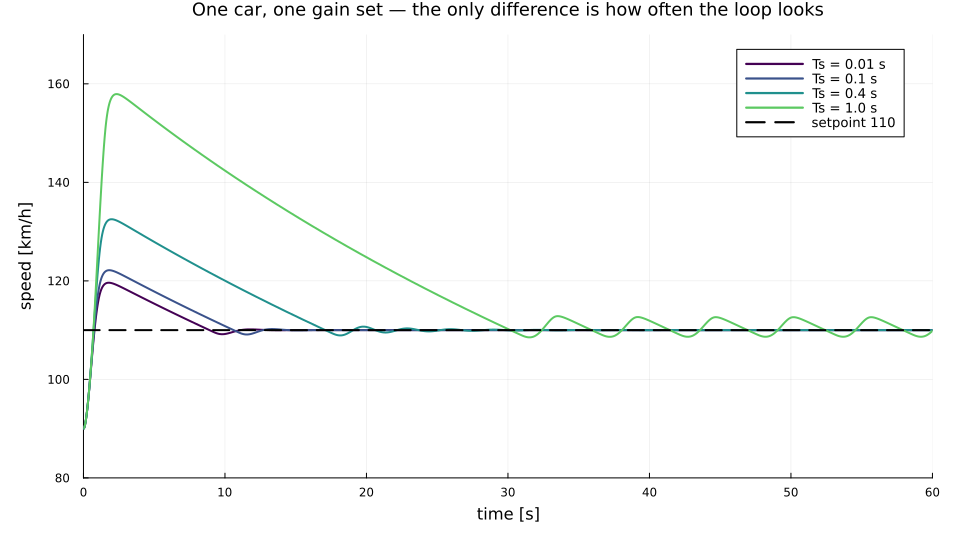

In [4]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED     = "loop.plant.v_kmh"
SETPOINT  = 110.0       # km/h
V_START   = 90.0        # km/h
UNLIMITED = 1.0e6       # N.m — the torque ceiling, lifted as it was in notebooks 03 to 05

# Notebook 08's Ziegler-Nichols gains, and the measurement they came from.
K_ZN, TI_ZN, TD_ZN = 67.39, 1.087, 0.272
KU, PU = 114.56, 2.175  # N.m per km/h, s — the continuous ultimate gain and period

TSPAN = (0.0, 120.0)
SAMPLE_TIMES = [0.01, 0.1, 0.4, 1.0]

# `Ts` is structural — the Pade delay bakes its delay time in at construction — so this is one
# compiled model per sample time rather than a `sweep` over one of them.
sampled(Ts; k = K_ZN, Ti = TI_ZN, Td = TD_ZN, with_I = true, with_D = true, v_hi = SETPOINT) =
    Scenarios.SampledCruiseStep(; name = :SampledCruiseStep, Ts = Ts,
        with_I = with_I, with_D = with_D, wd = 0.0,
        k = k, Ti = Ti, Td = Td, v_lo = V_START, v_hi = v_hi,
        T_max = UNLIMITED, y_max = UNLIMITED)

problem(Ts; tspan = TSPAN, kwargs...) = ODEProblem(mtkcompile(sampled(Ts; kwargs...)), [], tspan)
solve_at(Ts; kwargs...) = solve(problem(Ts; kwargs...))

# The compiled problems are kept, not just their solutions: section 6 re-solves the one at
# Ts = 1 s with different gains, and that is a `remake` rather than another compile.
problems = [Ts => problem(Ts) for Ts in SAMPLE_TIMES]
runs = [Ts => solve(p) for (Ts, p) in problems]

# The spread over the last twenty seconds is the readout that separates "overshoots and
# settles" from "rings": a settled run has none, and a ringing one still has most of it.
println("  Ts [s]    Ts/Pu     peak [km/h]    overshoot    spread over the last 20 s")
for (Ts, sol) in runs
    t, v = signal(sol, SPEED)
    late = v[t .> 100]
    println("  ", rpad(Ts, 10), rpad(round(Ts / PU, digits = 3), 10),
            rpad(round(maximum(v), digits = 2), 15),
            rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED, y0 = V_START), digits = 1), " %"), 13),
            round(maximum(late) - minimum(late), digits = 3), " km/h")
end

family = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (0, 60),
              ylims = (80, 170), legend = :topright,
              title = "One car, one gain set — the only difference is how often the loop looks")
ramp = palette(:viridis, length(runs) + 1)
for (n, (Ts, sol)) in enumerate(runs)
    plot!(family, signal(sol, SPEED)...; lw = 2, color = ramp[n], label = "Ts = $Ts s")
end
hline!(family, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")

save_figure(family, "09-sample-time-family")
family

## 4. Why it destabilizes

Read the family left to right and the failure arrives in three stages. At one hundredth of a
second the trace is the continuous design and nothing about it hints that a sampler exists. At
a tenth and at four tenths the overshoot grows — 122 km/h, then 132 — and both still settle. At
one second the car reaches 158 km/h and then never stops swinging: the ripple in the last
twenty seconds is 4 km/h wide and it is not shrinking. Same car, same three gains, four
sample periods.

A zero-order hold delays the average command by about half a sample period, so at frequency
$\omega$ it costs the loop

$$
\Delta\varphi \;\approx\; -\,\frac{\omega\,T_s}{2}\ \text{radians}
$$

Phase margin is a finite budget, and the tuning has already spent most of it. Ziegler-Nichols
in particular is a method that spends nearly all of it deliberately: it is derived from the gain
at which the loop oscillates and it sits close to that boundary on purpose. There is very little
left to give away.

- Spend a little of it: more overshoot.
- Spend most of it: the loop rings.
- Spend all of it: it does not recover.

The rule of thumb worth keeping is a budget in the same units. Spend at most about 0.2 rad —
roughly 12 degrees — of phase on sampling at the loop's crossover frequency $\omega_c$, which
is $T_s < 0.4/\omega_c$. In words: **sample twenty to thirty times faster than the closed-loop
bandwidth**, not than the plant. The car's own time constant is about a minute and it tells you
nothing whatever about how fast you must sample. The controller you wrapped around it is what
sets the rate.

## 5. Measuring the plant through the sampler

There are two fixes, and they are not equivalent.

**Sample faster.** Buy the phase back. This is a hardware conversation — a faster loop rate
means a more expensive processor, more power, more heat, and on a shared bus an argument with
whatever else was using it. It is also the fix that costs nothing in control performance, which
is exactly why it is worth having the argument.

**Re-tune for the rate you actually have.** Treat the slow sample rate as part of the plant,
measure *that* plant, and tune from the measurement. The loop comes back to stability — and it
comes back slower, permanently, because the gains that are safe at this rate are lower than the
ones that were safe continuously.

The second fix needs a number before it can be applied, so this section goes and gets it: the
ultimate gain and period of the loop **with the sampler in it**, by the same walk-the-gain
experiment notebook 08 ran without one.

In [5]:
# Ziegler-Nichols step 2, repeated with the sampler in the loop: raise the proportional gain
# until the oscillation neither grows nor decays. Integral and derivative paths off, and the
# setpoint poked by a tenth of a km/h so the swing stays in the linear region — the same three
# decisions notebook 08 made, for the same reasons.
DELTA   = 0.1       # km/h
TS_SLOW = 1.0       # s

function oscillation(sol; from = 6.0)
    t, y = signal(sol, SPEED)
    keep = t .>= from                 # past the step's own first swing
    t, y = t[keep], y[keep]
    peaks = [i for i in 2:(length(y) - 1) if y[i] > y[i - 1] && y[i] >= y[i + 1]]
    amps = [y[p] - minimum(@view y[p:q]) for (p, q) in zip(peaks[1:(end - 1)], peaks[2:end])]
    ratios = amps[2:end] ./ amps[1:(end - 1)]
    return (period = sum(diff(t[peaks])) / (length(peaks) - 1),
            ratio = sum(ratios) / length(ratios))
end

probe = problem(TS_SLOW; with_I = false, with_D = false, v_hi = V_START + DELTA,
                tspan = (0.0, 60.0))
# Below k = 15 the run decays before it completes three peaks, and an amplitude ratio needs
# three; the ladder therefore starts where the measurement is defined.
SLOW_GAINS = [15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 60.0]
ladder = sweep(probe, "k", SLOW_GAINS)
walk = [(k = k, osc = oscillation(sol)) for (k, sol) in ladder]

println("  k        period [s]   amplitude ratio per cycle")
for w in walk
    println("  ", rpad(w.k, 9), rpad(round(w.osc.period, digits = 3), 13),
            round(w.osc.ratio, digits = 4))
end

# The same interpolation notebook 08 used: the ratio is monotonic in the gain, so the gain at
# which it reaches one lies between the two runs either side of the crossing.
crossing = findlast(w -> w.osc.ratio < 1, walk)
below, above = walk[crossing], walk[crossing + 1]
Ku_slow = below.k + (1 - below.osc.ratio) * (above.k - below.k) / (above.osc.ratio - below.osc.ratio)
Pu_slow = oscillation(rerun(probe, "k" => Ku_slow)).period

println()
println("at Ts = ", TS_SLOW, " s      Ku = ", rpad(round(Ku_slow, digits = 2), 8),
        " N.m per km/h    Pu = ", round(Pu_slow, digits = 3), " s")
println("continuously        Ku = ", rpad(KU, 8), " N.m per km/h    Pu = ", PU, " s")
println("the sampler cost    ", round(100 * (1 - Ku_slow / KU), digits = 1),
        " % of the ultimate gain")

  k        period [s]   amplitude ratio per cycle
  15.0     9.33         0.0071
  20.0     7.674        0.0511
  25.0     6.031        0.1441
  30.0     5.408        0.2412
  40.0     4.587        0.6098
  50.0     4.299        1.0074
  60.0     4.389        1.0012

at Ts = 1.0 s      Ku = 49.82    N.m per km/h    Pu = 4.294 s
continuously        Ku = 114.56   N.m per km/h    Pu = 2.175 s
the sampler cost    56.5 % of the ultimate gain


One second of sample period cost this loop **more than half its ultimate gain** — 114.56 N.m
per km/h down to 49.82 — and doubled its ultimate period, from 2.175 s to 4.294. Both numbers
say the same thing in different units: the plant the slow controller is looking at is a slower,
more sluggish, less forgiving plant than the one notebook 08 measured, and it is less forgiving
by a factor that no amount of care with the original gains can recover.

Two things about the ladder itself are worth a glance before moving on.

**The period grows as the gain falls**, from 4.3 s at the boundary to 9.3 s at `k` = 15. That is
normal — a lightly excited loop oscillates near its own natural frequency and a hard-driven one
near the boundary frequency — and it is why the period has to be read *at* `Ku` rather than
averaged over the walk.

**The amplitude ratio stops climbing once it reaches one.** `k` = 50 reports 1.0074 and `k` = 60
reports 1.0012, which is not the monotone rise the interpolation assumes. It is the same clamp
notebook 08 warned about: `y_min` is nailed to zero because a petrol engine has no reverse
torque path, so a swing large enough to ask for braking squares off against that floor and the
growth turns into a limit cycle with an amplitude the clamp sets rather than the gain. The
crossing is therefore read from the two runs either side of it — 40 and 50 — where the
oscillation is still linear, and everything above is a different experiment.

## 6. Both fixes, at one second

The re-tuned gains are what Ziegler-Nichols says about the plant the slow controller actually
sees. The other fix needs nothing said about it at all — it is the same gains at a faster rate.

Ziegler-Nichols, applied to the measurement made through the sampler
  k  = 29.3     against 67.39 continuously
  Ti = 2.147    against 1.087
  Td = 0.537    against 0.272

                                     rise 10-90 [s]   overshoot   settled [km/h]
  continuous design, Ts = 0.01 s 0.53             48.1 %      110.0
  gains from 08, Ts = 1 s        0.48             239.6 %     110.41
  gains from 08, Ts = 0.05 s     0.52             53.5 %      110.0
  re-tuned for Ts = 1 s          0.91             51.8 %      110.0


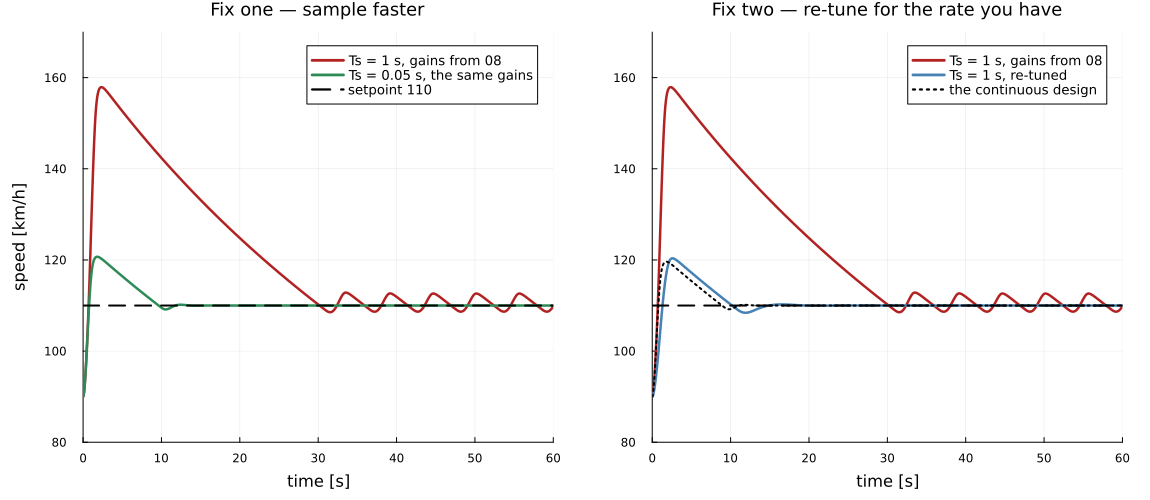

In [6]:
k2, Ti2, Td2 = ziegler_nichols(Ku_slow, Pu_slow)

println("Ziegler-Nichols, applied to the measurement made through the sampler")
println("  k  = ", rpad(round(k2, digits = 2), 8), " against ", K_ZN, " continuously")
println("  Ti = ", rpad(round(Ti2, digits = 3), 8), " against ", TI_ZN)
println("  Td = ", rpad(round(Td2, digits = 3), 8), " against ", TD_ZN)
println()

TS_FAST = 0.05      # s — twenty times faster, and the gains never move

continuous    = last(first(runs))    # Ts = 0.01, the design as notebook 08 left it
original_slow = last(last(runs))     # Ts = 1 s, section 3's worst case
retuned_slow  = rerun(last(last(problems)), "k" => k2, "Ti" => Ti2, "Td" => Td2)

# The only new compile in this cell: `Ts` is structural, so a faster rate is a different model.
faster = solve_at(TS_FAST)

println("                                     rise 10-90 [s]   overshoot   settled [km/h]")
for (name, sol) in (("continuous design, Ts = 0.01 s ", continuous),
                    ("gains from 08, Ts = 1 s        ", original_slow),
                    ("gains from 08, Ts = 0.05 s     ", faster),
                    ("re-tuned for Ts = 1 s          ", retuned_slow))
    t, v = signal(sol, SPEED)
    println("  ", name,
            rpad(round(rise_time(sol, SETPOINT; sig = SPEED, y0 = V_START), digits = 2), 17),
            rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED, y0 = V_START), digits = 1), " %"), 12),
            round(sum(v[t .> 100]) / length(v[t .> 100]), digits = 2))
end

faster_fix = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (0, 60),
                  ylims = (80, 170), legend = :topright, title = "Fix one — sample faster")
plot!(faster_fix, signal(original_slow, SPEED)...; lw = 2.5, color = :firebrick,
      label = "Ts = 1 s, gains from 08")
plot!(faster_fix, signal(faster, SPEED)...; lw = 2.5, color = :seagreen,
      label = "Ts = 0.05 s, the same gains")
hline!(faster_fix, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")

retune_fix = plot(; xlabel = "time [s]", xlims = (0, 60), ylims = (80, 170), legend = :topright,
                  title = "Fix two — re-tune for the rate you have")
plot!(retune_fix, signal(original_slow, SPEED)...; lw = 2.5, color = :firebrick,
      label = "Ts = 1 s, gains from 08")
plot!(retune_fix, signal(retuned_slow, SPEED)...; lw = 2.5, color = :steelblue,
      label = "Ts = 1 s, re-tuned")
plot!(retune_fix, signal(continuous, SPEED)...; lw = 2, ls = :dot, color = :black,
      label = "the continuous design")
hline!(retune_fix, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "")

fixes = plot(faster_fix, retune_fix; layout = (1, 2), size = (1150, 500))
save_figure(fixes, "09-retuned")
fixes

Both fixes work, and they cost different things.

**Sampling twenty times faster puts the response back exactly where it was.** 0.52 s to rise
against the continuous design's 0.53, and the ripple is gone. This fix costs nothing in control
and everything in hardware, which is the whole of the argument you will be having with whoever
owns the processor budget.

**Re-tuning works too, and the loop it gives back is a slower loop.** Half the gain (29.3
against 67.39), twice the integral time, twice the derivative time, and a rise that takes 0.91 s
instead of 0.53. Nothing recovers that 70 %: it is the price of an information rate, and paying
it in gain is the only currency the controller has. The re-tuned trace tracks the continuous
design's shape and arrives late, which is exactly what section 2's strobe-lit corridor
predicted.

**One number in that table is the surrogate showing through, and it is worth naming.** The
re-tuned loop is quoted as rising in 0.91 s at a sample period of one second — a real digital
controller could not do that, because for most of that rise it would not yet have looked. The
half-sample delay reproduces the phase a hold costs but not the hold itself, so this model goes
on responding continuously between ticks. Read the table for the trend between rows, which is
faithful, and not for the sub-sample detail inside one, which is not.

## 7. Why design in continuous time at all?

Given that the controller is going to run on a clock, it is fair to ask why anyone starts
anywhere else. Three reasons, and none of them is inertia.

- **The mathematics is easier and far better tooled.** Transfer functions, root loci, Bode
  plots, every table in notebook 08 — all of it is continuous-time machinery, and the discrete
  equivalents are later, thinner and less familiar.
- **The plant is continuous anyway.** The car does not tick. Designing in discrete time means
  choosing the sample rate before you know what rate you need, which is the wrong way round.
- **One domain keeps the problem simple.** One model, one set of units, one kind of stability
  argument.

So: **design continuous, convert, then verify that the rate you actually have held up** — which
is precisely the plot in section 3. That verification is not a formality. The gains out of
notebook 08 are correct, and at one sample a second they produce a car that does not settle.

## What this bought us

A loop broken without touching a single gain, and a reason: sampling costs phase, and phase
margin is a budget that a good tuning has already spent most of. The car never changed. The
controller never changed. Only the rate at which the two met.

Three things worth carrying out of this notebook.

- **The sample rate belongs to the controller, not the plant.** This car's own time constant is
  about a minute and it is no guide at all. The closed loop's bandwidth is what sets the rate,
  and notebook 08's `Pu` is the number to hold a candidate `Ts` against.
- **Re-tuning buys back stability, not performance.** The slow loop is a slower loop, forever.
  If the performance mattered, the fix was the faster processor.
- **A design verified only in continuous time has not been verified.** The conversion is where a
  correct controller becomes an unstable one, silently, with no warning from any of the tools
  that produced it.

**Notebook 10** leaves the actuator alone and goes after the last assumption standing: that the
torque the engine delivers reaches the road. The tire is an actuator too, and it saturates.